Task 2
Solution with Dataframe API
+----+---------------+
|year|max_temperature|
+----+---------------+
|1901|31.7           |
|1902|24.4           |
+----+---------------+

Solution with Spark SQL
+----+---------------+
|year|max_temperature|
+----+---------------+
|1901|31.7           |
|1902|24.4           |
+----+---------------+

Task 5
5.1 Summary statistics (DataFrame API)
+----+-----+------------------+------------------+-----+----+
|year|count|mean              |stddev            |min  |max |
+----+-----+------------------+------------------+-----+----+
|1901|6564 |4.669850700792205 |10.607426578657943|-33.3|31.7|
|1902|6565 |2.1659558263518717|8.904442957112824 |-32.8|24.4|
+----+-----+------------------+------------------+-----+----+

5.1 Summary statistics (Spark SQL)
+----+-----+------------------+------------------+-----+----+
|year|count|mean              |stddev            |min  |max |
+----+-----+------------------+------------------+-----+----+
|1901|6564 |4.669850700

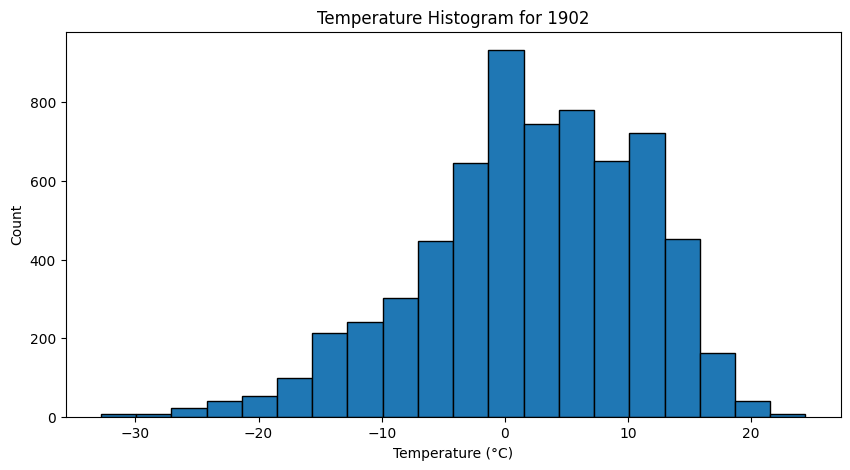

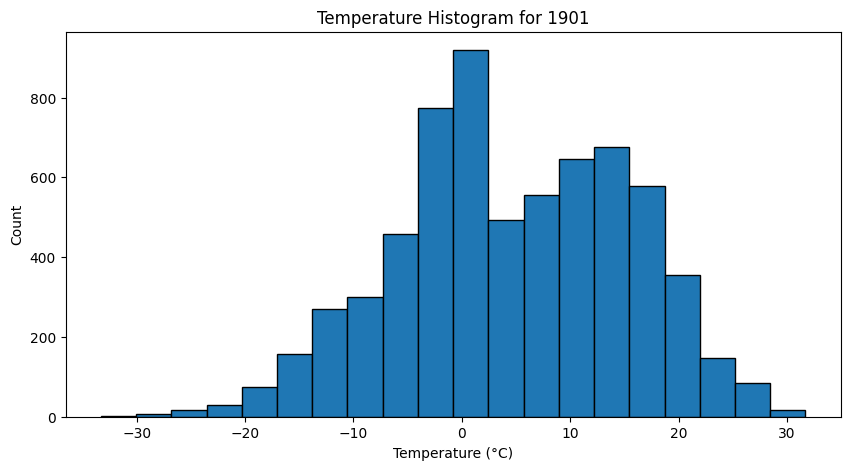

5.4 Weather-Station-Join
+------------+----+-----+-------------------+------------------+-----+----+
|station_name|year|count|mean               |stddev            |min  |max |
+------------+----+-----+-------------------+------------------+-----+----+
|            |1901|2190 |4.720319634703198  |10.622403765274354|-27.2|30.6|
|            |1902|2190 |2.374611872146125  |8.691222301739844 |-32.8|20.6|
|TURKU       |1901|1092 |6.0639194139194155 |11.28252375480074 |-23.9|31.7|
|TURKU       |1902|1095 |3.508858447488584  |8.916456863117078 |-26.1|22.8|
|ULKOKALLA   |1901|1095 |3.0458447488584355 |9.548764413384081 |-25.0|23.9|
|ULKOKALLA   |1902|1091 |0.3853345554537153 |8.207612563557964 |-26.1|15.6|
|UTO         |1901|1093 |6.489021043000919  |8.249515928329046 |-10.6|29.4|
|UTO         |1902|1094 |4.247074954296163  |5.850080788601908 |-12.2|17.2|
|VYARTSILYA  |1901|1094 |2.985283363802562  |12.352464484097279|-33.3|30.6|
|VYARTSILYA  |1902|1095 |0.10063926940639423|11.407117536290938

In [0]:
from pyspark.sql.functions import spark_partition_id, countDistinct, col, substring, max, min, count, mean, stddev, sum, floor, when, trim

# Import the data
path = "/Volumes/workspace/default/data/assignment4"
stations_path = path + "/weather-station/stations-fixed-width.txt" #will be needed later (5.4)

rawDf = spark.read.text(path) \
    .withColumn("source_file", col("_metadata.file_path"))

# Create a table for SQL queries
df = rawDf \
    .withColumn("usaf", col("value").substr(5, 6)) \
    .withColumn("wban", col("value").substr(11, 5)) \
    .withColumn("year", col("value").substr(16, 4).cast("int")) \
    .withColumn("temp_raw", col("value").substr(88, 5)) \
    .withColumn("quality", col("value").substr(93, 1)) \
    .withColumn("temperature_int", col("temp_raw").cast("int"))

# Filter valid temperature records
df_clean = df \
    .filter(col("temperature_int") != 9999) \
    .filter(col("quality").isin("0", "1", "4", "5", "9")) \
    .withColumn("temperature", col("temperature_int") / 10)

print("Task 2")
print("Solution with Dataframe API")
maxTempPerYear_df = df_clean \
    .groupBy("year") \
    .agg(max("temperature").alias("max_temperature")) \
    .orderBy("year")
maxTempPerYear_df.show(truncate=False)

print("Solution with Spark SQL")
df_clean.createOrReplaceTempView("weather")
maxTempPerYear_sql = spark.sql("""
    SELECT
        year,
        MAX(temperature) AS max_temperature
    FROM weather
    GROUP BY year
    ORDER BY year
""")
maxTempPerYear_sql.show(truncate=False)

print("Task 5")
print("5.1 Summary statistics (DataFrame API)")
stats_df = df_clean \
    .groupBy("year") \
    .agg(
        count("temperature").alias("count"),
        mean("temperature").alias("mean"),
        stddev("temperature").alias("stddev"),
        min("temperature").alias("min"),
        max("temperature").alias("max")
    ) \
    .orderBy("year")
stats_df.show(truncate=False)

print("5.1 Summary statistics (Spark SQL)")
df_clean.createOrReplaceTempView("weather_valid")
spark.sql("""
    SELECT
        year,
        COUNT(temperature) AS count,
        AVG(temperature) AS mean,
        STDDEV(temperature) AS stddev,
        MIN(temperature) AS min,
        MAX(temperature) AS max
    FROM weather_valid
    GROUP BY year
    ORDER BY year
""").show(truncate=False)

print("5.2 Missing and malformed records")
quality_valid = ["0", "1", "4", "5", "9"]

invalid_stats = df \
    .groupBy("year") \
    .agg(
        sum((col("temperature_int") == 9999).cast("int")).alias("missing_records"),
        sum((~col("quality").isin(*quality_valid)).cast("int")).alias("malformed_records"),
        count("*").alias("total_records")
    ) \
    .orderBy("year")
invalid_stats.show(truncate=False)


print("5.3 Histogram data per year (DataFrame-safe)")

num_bins = 20
histograms_df = {}

years = [r["year"] for r in df_clean.select("year").distinct().collect()]

for y in years:
    year_df = df_clean.filter(col("year") == y)

    # min/max Temperatur pro Jahr
    min_temp = year_df.agg(min("temperature")).collect()[0][0]
    max_temp = year_df.agg(max("temperature")).collect()[0][0]

    bin_width = (max_temp - min_temp) / num_bins

    # Add a "bin" column
    year_df_bins = year_df.withColumn(
        "bin",
        floor((col("temperature") - min_temp) / bin_width)
    )

    # Edge case: max temperature = last bin
    year_df_bins = year_df_bins.withColumn(
        "bin",
        when(col("bin") >= num_bins, num_bins - 1).otherwise(col("bin"))
    )

    # Count values per bin
    bin_counts = year_df_bins.groupBy("bin").count().orderBy("bin").collect()
    histograms_df[y] = [(row["bin"], row["count"]) for row in bin_counts]

import matplotlib.pyplot as plt

for year, hist_data in histograms_df.items():
    # hist_data ist [(bin_index, count), ...]
    bins, counts = zip(*hist_data)

    # min/max Temperatur für diesen Jahrgang
    min_temp = df_clean.filter(col("year") == year).agg(min("temperature")).collect()[0][0]
    max_temp = df_clean.filter(col("year") == year).agg(max("temperature")).collect()[0][0]
    num_bins = len(bins)
    bin_edges = [min_temp + i*(max_temp - min_temp)/num_bins for i in range(num_bins+1)]

    plt.figure(figsize=(10,5))
    plt.bar(bin_edges[:-1], counts, width=(max_temp - min_temp)/num_bins, align='edge', edgecolor='black')
    plt.xlabel("Temperature (°C)")
    plt.ylabel("Count")
    plt.title(f"Temperature Histogram for {year}")
    plt.show()

print("5.4 Weather-Station-Join")
stations = spark.read.text(stations_path) \
    .select(
        col("value").substr(1, 6).alias("usaf"),
        col("value").substr(8, 5).alias("wban"),
        trim(col("value").substr(13, 30)).alias("station_name")
    )

result = df_clean.join(
    stations,
    on=["usaf", "wban"],
    how="inner"
).groupBy(
    "station_name", "year"
).agg(
    count("temperature").alias("count"),
    mean("temperature").alias("mean"),
    stddev("temperature").alias("stddev"),
    min("temperature").alias("min"),
    max("temperature").alias("max")
).orderBy(
    "station_name", "year"
)

result.show(truncate=False)

